# NorthBay Living — Exploratory Data Analysis (v2 dataset)

Same method as the previous EDA notebook, run on the cleaned outputs of `data_cleaning.ipynb` (this version). Five cleaned files, kept as **separate tables** throughout, joined only temporarily in memory when a question needs it.

This dataset is noticeably richer than the last one — it has **real stockouts**, **real overstock outliers**, an **epidemic flag**, **seasonality/weather**, and discount/promotion that actually seem to move sales. EDA here is about confirming and quantifying those signals so they can directly feed the five project objectives (weekly SKU forecast, risk flags, ₹ impact, dashboard/service, stakeholder story).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
print("Libraries loaded.")


Libraries loaded.


## Step 0 — Load the cleaned data


In [2]:
sales = pd.read_csv('../Cleaned + Splitted/sales_daily_cleaned_v2.csv', parse_dates=['date'])
inventory = pd.read_csv('../Cleaned + Splitted/inventory_snapshots_cleaned_v2.csv', parse_dates=['date'])
sku = pd.read_csv('../Cleaned + Splitted/sku_master_cleaned_v2.csv')
calendar = pd.read_csv('../Cleaned + Splitted/calender_cleaned_v2.csv', parse_dates=['date'])
sales_data = pd.read_csv('../Cleaned + Splitted/sales_data_cleaned_v2.csv', parse_dates=['date'])

for name, df in [('sales', sales), ('inventory', inventory), ('sku', sku),
                  ('calendar', calendar), ('sales_data', sales_data)]:
    print(f"{name:12s} {df.shape}")


sales        (76000, 8)
inventory    (76000, 6)
sku          (100, 4)
calendar     (760, 12)
sales_data   (76000, 16)


## Part A — Univariate analysis


In [3]:
sales['units_sold'].describe()


count    76000.000000
mean        88.827316
std         43.994525
min          0.000000
25%         58.000000
50%         84.000000
75%        114.000000
max        426.000000
Name: units_sold, dtype: float64

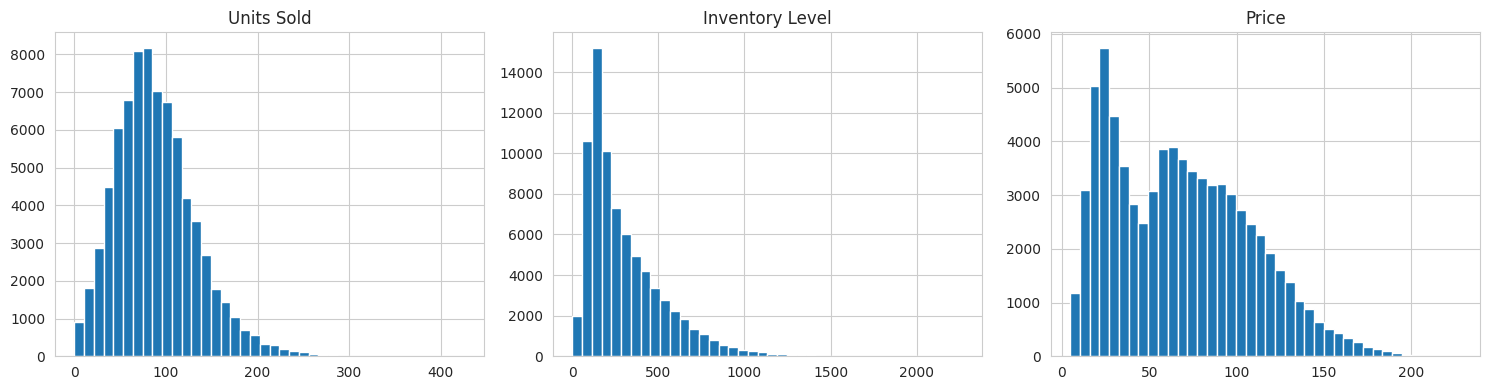

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sales['units_sold'].hist(bins=40, ax=axes[0]); axes[0].set_title('Units Sold')
inventory['inventory_level'].hist(bins=40, ax=axes[1]); axes[1].set_title('Inventory Level')
sales['price'].hist(bins=40, ax=axes[2]); axes[2].set_title('Price')
plt.tight_layout()
plt.show()


`units_sold` is right-skewed as before. `inventory_level` shows a much longer tail this time — a cluster of very high values well beyond the typical range, which is the overstock signal we flagged during cleaning. `price` spreads broadly across the range.


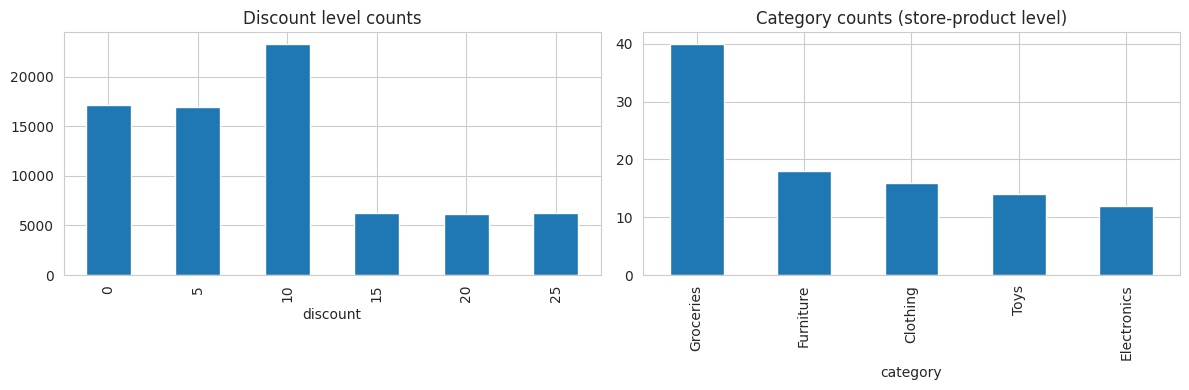

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sales['discount'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Discount level counts')
sku['category'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Category counts (store-product level)')
plt.tight_layout()
plt.show()


## Part B — Do price, discount, and promotion actually move demand this time?

The previous dataset showed essentially no relationship here. Cleaning already hinted this dataset is different — let's confirm with the full picture.


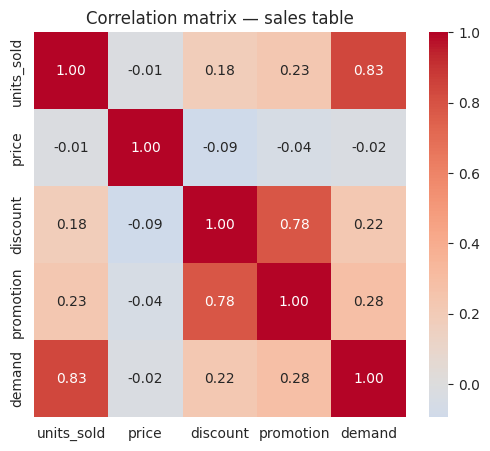

In [6]:
corr_cols = ['units_sold', 'price', 'discount', 'promotion', 'demand']
corr = sales[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix — sales table')
plt.show()


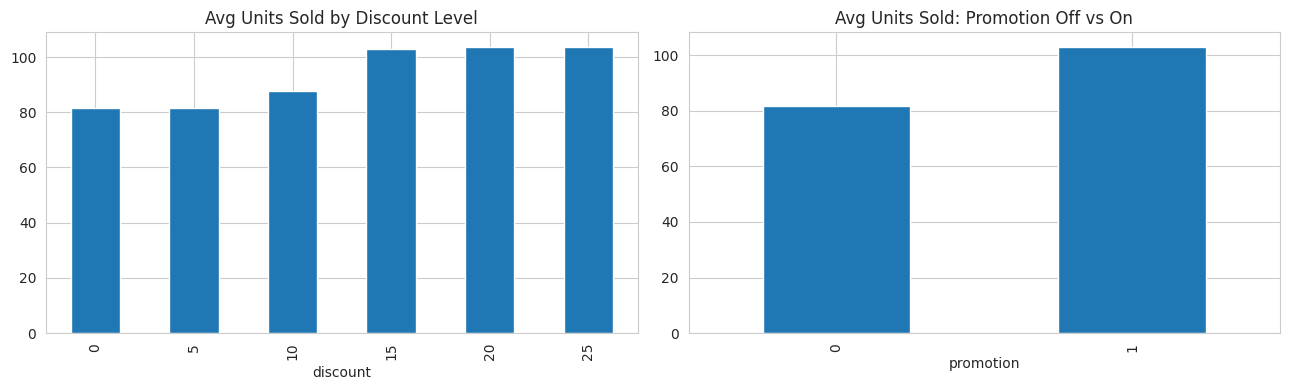

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sales.groupby('discount')['units_sold'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('Avg Units Sold by Discount Level')
sales.groupby('promotion')['units_sold'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('Avg Units Sold: Promotion Off vs On')
plt.tight_layout()
plt.show()


**Finding:** `discount` (corr ≈ 0.18) and `promotion` (corr ≈ 0.23) both show a real, visible positive relationship with `units_sold` — unlike the flat result from the previous dataset. These are genuinely useful signals to include as forecast features (objective 1), and they matter operationally too: promotions/discounts are a lever NorthBay can pull, which the risk-flagging layer should probably be aware of (e.g. don't recommend "clear" pricing on a SKU that's about to go on promotion anyway).


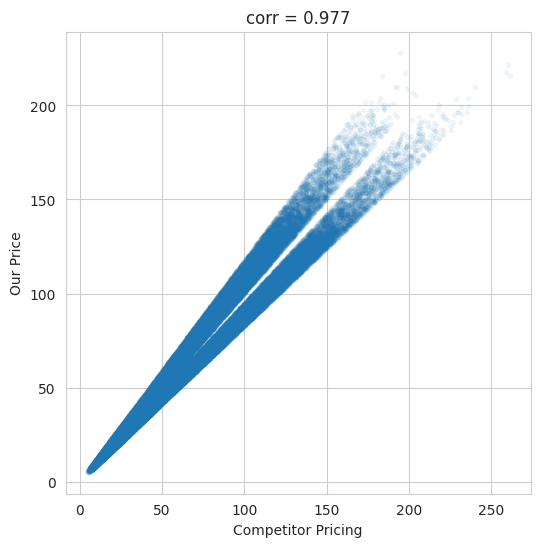

In [8]:
daily_pc = sales.merge(inventory, on=['date', 'store_id', 'product_id'])
plt.figure(figsize=(6, 6))
plt.scatter(daily_pc['competitor_pricing'], daily_pc['price'], alpha=0.05, s=8)
plt.xlabel('Competitor Pricing'); plt.ylabel('Our Price')
plt.title(f"corr = {daily_pc['price'].corr(daily_pc['competitor_pricing']):.3f}")
plt.show()


Our price tracks competitor pricing very closely (corr ≈ 0.98) — pricing here isn't set independently of the competitive landscape. Worth keeping in mind if we ever explore price-based interventions later, since our price and the competitor's move almost in lockstep.


## Part C — Time patterns: trend, seasonality, epidemic effect


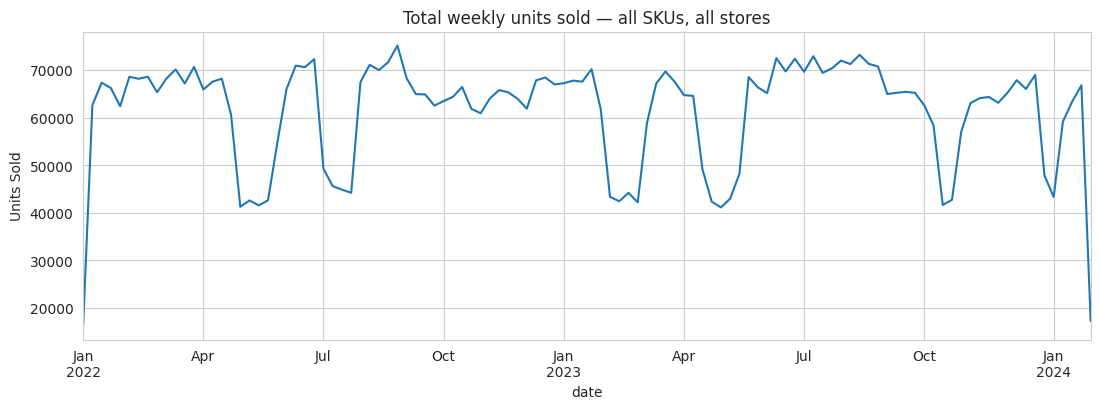

Trend correlation: -0.024
count      110.00000
mean     61371.60000
std      11392.42468
min      16285.00000
25%      59542.25000
50%      65284.50000
75%      68404.50000
max      75175.00000
Name: units_sold, dtype: float64


In [9]:
portfolio_weekly = sales.set_index('date').resample('W')['units_sold'].sum()

plt.figure(figsize=(13, 4))
portfolio_weekly.plot()
plt.title('Total weekly units sold — all SKUs, all stores')
plt.ylabel('Units Sold')
plt.show()

trend_corr = np.corrcoef(range(len(portfolio_weekly)), portfolio_weekly.values)[0, 1]
print(f"Trend correlation: {trend_corr:.3f}")
print(portfolio_weekly.describe())


No strong long-term trend (correlation ≈ -0.02), but notice the **much wider week-to-week swings** than the previous dataset (from ~16k to ~75k units/week) — there's a visible dip partway through. That's worth investigating directly, since it's a strong candidate for the epidemic effect below.


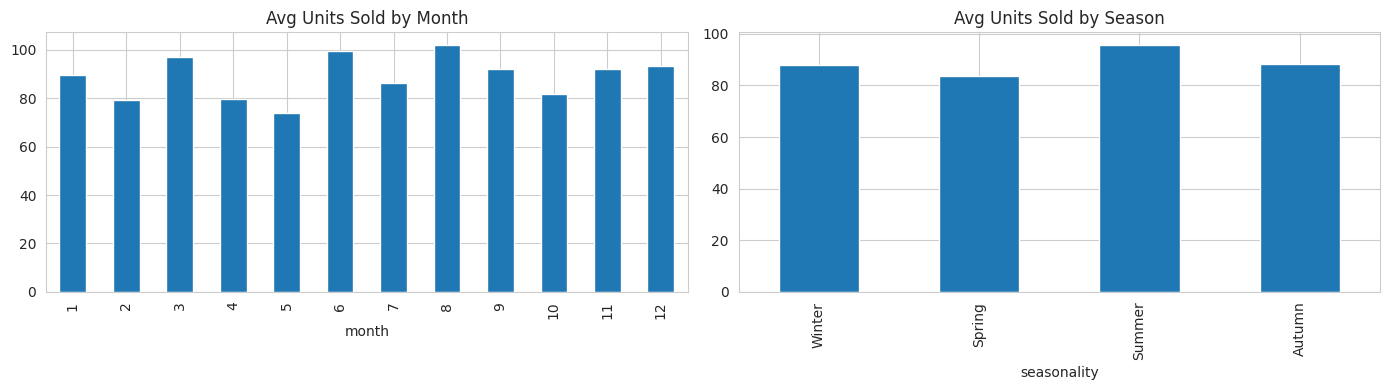

In [10]:
sales_cal = sales.merge(calendar[['date', 'month', 'dayname', 'isweekend', 'seasonality', 'epidemic']], on='date', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sales_cal.groupby('month')['units_sold'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('Avg Units Sold by Month')
sales_cal.groupby('seasonality')['units_sold'].mean().reindex(['Winter','Spring','Summer','Autumn']).plot(kind='bar', ax=axes[1])
axes[1].set_title('Avg Units Sold by Season')
plt.tight_layout()
plt.show()


There's real month-to-month variation this time (roughly 74 to 102 average units/day depending on month), and a mild seasonal pattern (Summer highest). Not dramatic, but real enough to be worth including as a forecast feature — unlike the previous dataset where every calendar cut was essentially flat.


epidemic
0    95.819211
1    60.859737
Name: units_sold, dtype: float64


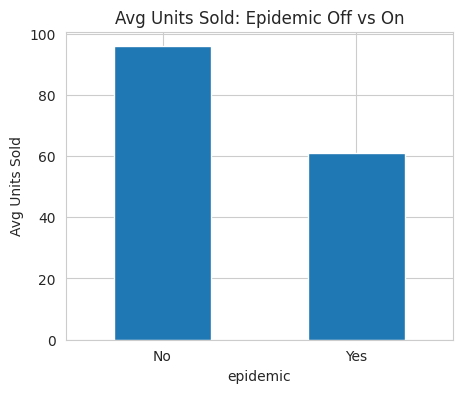


Demand drops about 36% during epidemic periods.


In [11]:
epidemic_effect = sales_cal.groupby('epidemic')['units_sold'].mean()
print(epidemic_effect)

plt.figure(figsize=(5, 4))
epidemic_effect.plot(kind='bar')
plt.title('Avg Units Sold: Epidemic Off vs On')
plt.ylabel('Avg Units Sold')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.show()

pct_drop = (1 - epidemic_effect[1] / epidemic_effect[0]) * 100
print(f"\nDemand drops about {pct_drop:.0f}% during epidemic periods.")


**This is the single biggest driver we've found:** average daily units sold drop by roughly a third during epidemic periods. This explains a large part of the wide week-to-week swings seen in the trend chart above. For objective 1, `epidemic` needs to be a forecast feature (or at minimum a scenario the model is evaluated against), since ignoring it would make forecasts systematically wrong during exactly the periods NorthBay most needs to plan carefully for.


weather_condition
Sunny     97.027937
Cloudy    89.625369
Rainy     81.972286
Snowy     80.948477
Name: units_sold, dtype: float64


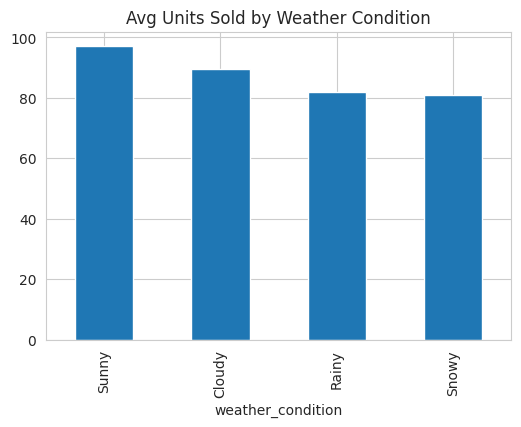

In [12]:
weather_effect = sales_data.groupby('weather_condition')['units_sold'].mean().sort_values(ascending=False)
print(weather_effect)

plt.figure(figsize=(6, 4))
weather_effect.plot(kind='bar')
plt.title('Avg Units Sold by Weather Condition')
plt.show()


Weather shows a smaller but visible effect (Sunny highest, Snowy/Rainy lower). Less important than the epidemic effect, but worth keeping as a secondary feature if it's available at forecast time.


### Day-of-week / weekend check (for completeness)


In [13]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
print(sales_cal.groupby('dayname')['units_sold'].mean().reindex(dow_order))
print("\nWeekend vs weekday:")
print(sales_cal.groupby('isweekend')['units_sold'].mean())


dayname
Monday       87.869450
Tuesday      88.416239
Wednesday    89.552500
Thursday     88.875648
Friday       89.178056
Saturday     88.956330
Sunday       88.953303
Name: units_sold, dtype: float64

Weekend vs weekday:
isweekend
False    88.776033
True     88.954817
Name: units_sold, dtype: float64


No meaningful day-of-week or weekend effect — flat, like the previous dataset. The signal in this data is coming from month/season and especially the epidemic flag, not the weekly calendar rhythm.


## Part D — Store, region, and category patterns

Remember from cleaning: `category` varies by **store + product**, not by product alone, so we group accordingly here.


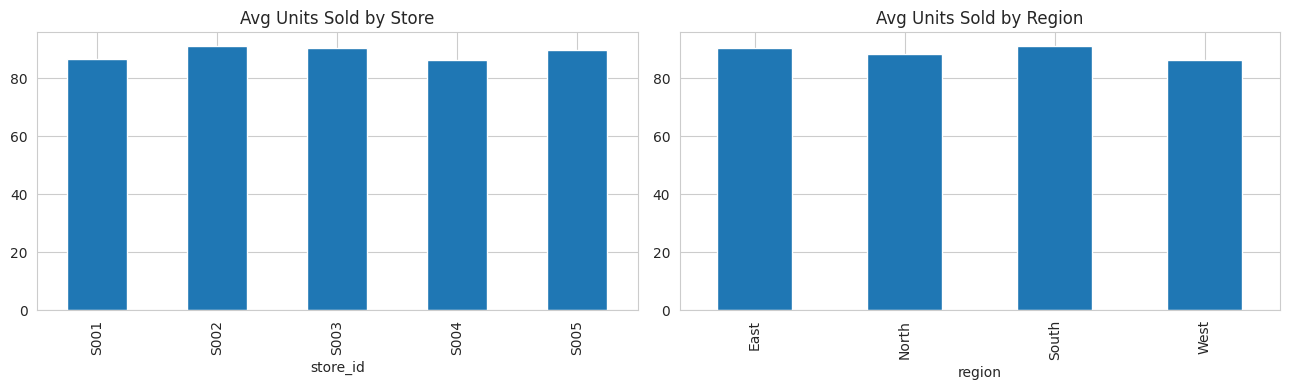

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sales.groupby('store_id')['units_sold'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('Avg Units Sold by Store')
sales_data.groupby('region')['units_sold'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('Avg Units Sold by Region')
plt.tight_layout()
plt.show()


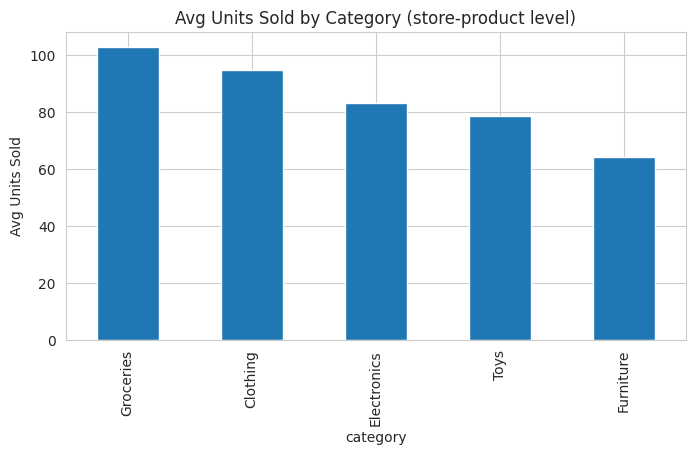

In [15]:
plt.figure(figsize=(8, 4))
sales_data.groupby('category')['units_sold'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Avg Units Sold by Category (store-product level)')
plt.ylabel('Avg Units Sold')
plt.show()


**Finding:** category shows real differentiation this time — Groceries sells noticeably more on average (~103/day) than Furniture (~64/day). Region and store differences are smaller but present. This is useful for objective 2/3: some categories are naturally higher-velocity and will need different reorder thresholds than others.


### Per-SKU demand volatility


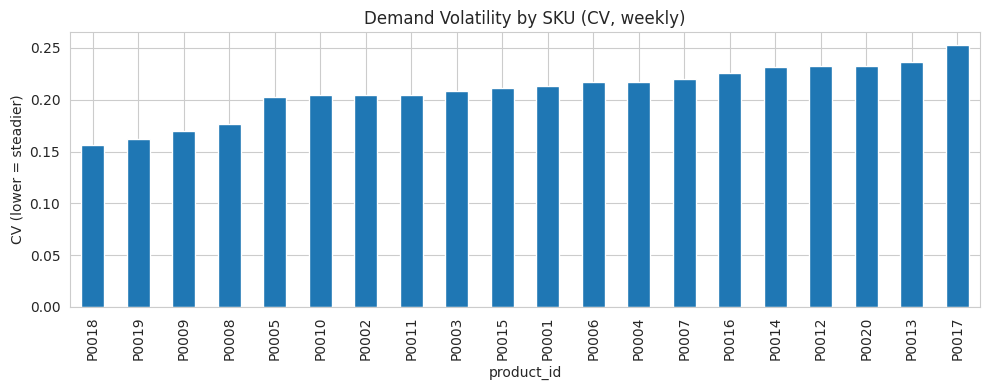

,mean,std,cv
product_id,,,
P0018,2823.61,440.95,0.16
P0019,2847.35,462.14,0.16
P0009,3425.19,582.08,0.17
P0008,2939.25,518.32,0.18
P0005,3197.86,647.52,0.20
P0010,3248.17,663.81,0.20
P0002,3266.86,668.91,0.20
P0011,3026.21,620.27,0.20
P0003,3104.83,647.83,0.21


In [16]:
weekly_by_sku = sales.set_index('date').groupby('product_id').resample('W')['units_sold'].sum().reset_index()
sku_volatility = weekly_by_sku.groupby('product_id')['units_sold'].agg(['mean', 'std'])
sku_volatility['cv'] = sku_volatility['std'] / sku_volatility['mean']
sku_volatility = sku_volatility.sort_values('cv')

plt.figure(figsize=(10, 4))
sku_volatility['cv'].plot(kind='bar')
plt.title('Demand Volatility by SKU (CV, weekly)')
plt.ylabel('CV (lower = steadier)')
plt.tight_layout()
plt.show()

sku_volatility.round(2)


**Finding:** CV now ranges from about 0.16 to 0.25 — a wider spread than the previous dataset's tight 0.16–0.19 band. Some SKUs (e.g. the ones at the low end) will be noticeably easier to forecast accurately than others (high end) — objective 1's evaluation should probably be reported per-SKU, not just as one blended number, so weak spots don't hide behind an overall average.


## Part E — How good is the existing `demand` column?

Same role as `demand_forecast` in the previous dataset — a benchmark to beat for objective 1.


In [17]:
sales['abs_error'] = (sales['demand'] - sales['units_sold']).abs()
mae = sales['abs_error'].mean()
mape = (sales['abs_error'] / sales['units_sold'].replace(0, np.nan)).mean() * 100
print(f"Existing demand column — MAE: {mae:.2f} units, MAPE: {mape:.1f}%")


Existing demand column — MAE: 21.05 units, MAPE: 32.1%


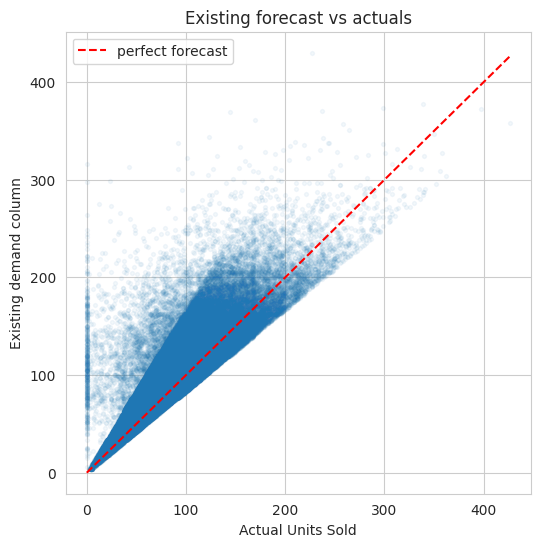

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(sales['units_sold'], sales['demand'], alpha=0.05, s=8)
lims = [0, sales['units_sold'].max()]
plt.plot(lims, lims, color='red', linestyle='--', label='perfect forecast')
plt.xlabel('Actual Units Sold'); plt.ylabel('Existing demand column')
plt.legend()
plt.title('Existing forecast vs actuals')
plt.show()


**Finding:** the existing `demand` column has about **32% MAPE** at the daily level — noticeably worse than the 23% we saw in the previous dataset's forecast column. That's actually good news for the project: there's more visible room for our weekly SKU-level model to demonstrate improvement over the existing baseline (objective 1).


## Part F — Stockout and overstock risk: now with real events to learn from

Unlike the previous dataset, `inventory_level` genuinely hits 0 here, so we can measure historical stockouts directly — no proxy needed for *detecting* past events, though we still build a **days-of-cover** metric to assess ongoing risk going forward.


Historical stockout rows: 406 (0.53% of all inventory rows)


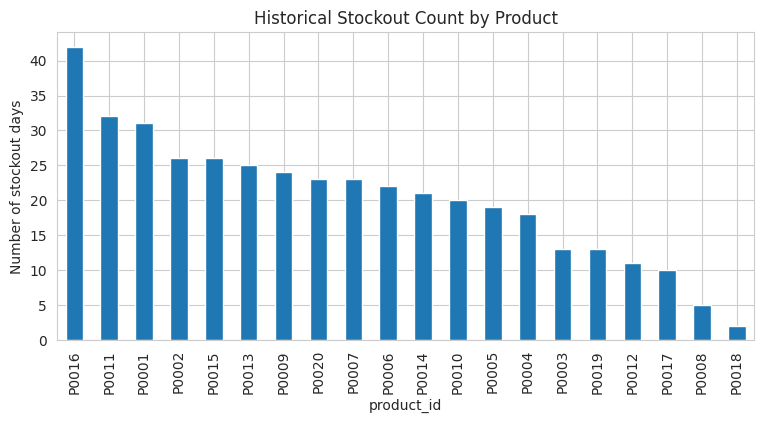

In [19]:
n_stockouts = (inventory['inventory_level'] == 0).sum()
print(f"Historical stockout rows: {n_stockouts} ({n_stockouts/len(inventory)*100:.2f}% of all inventory rows)")

stockout_by_product = inventory[inventory['inventory_level'] == 0].groupby('product_id').size().sort_values(ascending=False)
plt.figure(figsize=(9, 4))
stockout_by_product.plot(kind='bar')
plt.title('Historical Stockout Count by Product')
plt.ylabel('Number of stockout days')
plt.show()


Stockouts aren't spread evenly — a handful of SKUs (e.g. `P0016`, `P0011`, `P0001`) account for a disproportionate share. These are strong first candidates to watch closely once the reorder-flag logic (objective 2) is built.


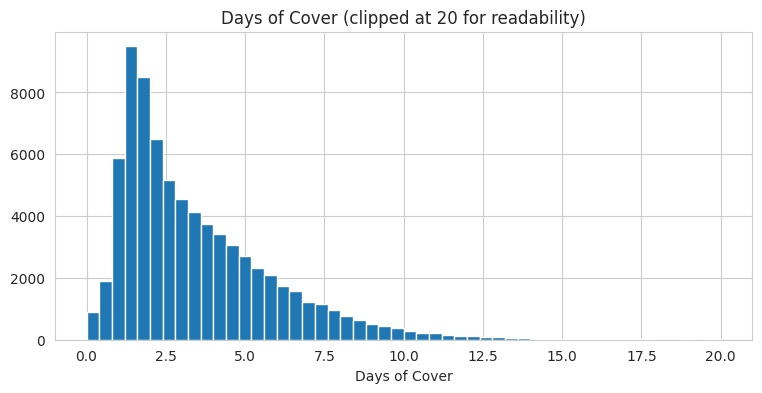

10th percentile: 1.15 days  |  median: 2.75 days  |  90th percentile: 6.86 days


In [20]:
daily = sales.merge(inventory, on=['date', 'store_id', 'product_id'])
daily = daily.sort_values(['store_id', 'product_id', 'date'])

daily['avg_daily_demand_14d'] = (
    daily.groupby(['store_id', 'product_id'])['units_sold']
         .transform(lambda s: s.rolling(14, min_periods=7).mean())
)
daily['days_of_cover'] = daily['inventory_level'] / daily['avg_daily_demand_14d'].replace(0, np.nan)

plt.figure(figsize=(9, 4))
daily['days_of_cover'].dropna().clip(upper=20).hist(bins=50)
plt.title('Days of Cover (clipped at 20 for readability)')
plt.xlabel('Days of Cover')
plt.show()

p10, p50, p90 = daily['days_of_cover'].quantile([0.10, 0.50, 0.90])
print(f"10th percentile: {p10:.2f} days  |  median: {p50:.2f} days  |  90th percentile: {p90:.2f} days")


**Finding:** typical coverage is about 2–3 days (median ≈ 2.75), with a meaningful tail stretching out to 37 days for the most overstocked SKU-days. Unlike the previous dataset, this distribution has real spread and real zeros, so **percentile-based thresholds here (e.g. bottom 10% ≈ 1.1 days → stockout risk, top 10% ≈ 6.9 days → overstock risk) are grounded in actual observed extremes**, not just a theoretical construct. This gives objective 2 a solid, defensible starting point.


## Part G — Rough ₹ impact (objective 3 preview)

Two estimates, both still rough first passes:

1. **Capital locked in inventory** on the most recent date in the data.
2. **Revenue lost to historical stockouts** — for every stockout row, we estimate the gap between the `demand` estimate and actual `units_sold` (since inventory was 0, any shortfall likely reflects unmet demand) and value it at that day's price.


In [21]:
latest_date = inventory['date'].max()
snapshot = inventory[inventory['date'] == latest_date].merge(
    sales[sales['date'] == latest_date][['store_id', 'product_id', 'price']],
    on=['store_id', 'product_id'], how='left'
)
snapshot['capital_locked'] = snapshot['inventory_level'] * snapshot['price']
print(f"Snapshot date: {latest_date.date()}")
print(f"Estimated capital tied up in inventory: ₹{snapshot['capital_locked'].sum():,.0f}")


Snapshot date: 2024-01-30
Estimated capital tied up in inventory: ₹2,027,707


In [22]:
stockout_rows = daily[daily['inventory_level'] == 0].copy()
stockout_rows['lost_units'] = (stockout_rows['demand'] - stockout_rows['units_sold']).clip(lower=0)
stockout_rows['lost_revenue'] = stockout_rows['lost_units'] * stockout_rows['price']

print(f"Stockout rows analyzed: {len(stockout_rows)}")
print(f"Estimated total lost revenue from historical stockouts: ₹{stockout_rows['lost_revenue'].sum():,.0f}")

print("\nLost revenue by product (top 5):")
print(stockout_rows.groupby('product_id')['lost_revenue'].sum().sort_values(ascending=False).head())


Stockout rows analyzed: 406
Estimated total lost revenue from historical stockouts: ₹3,028,090

Lost revenue by product (top 5):
product_id
P0011    354872.68
P0016    286972.40
P0009    263660.16
P0014    251996.98
P0015    231444.05
Name: lost_revenue, dtype: float64


**Finding:** even this rough first pass shows a meaningful ₹ figure in both directions — capital sitting in inventory on any given day, and revenue historically lost to stockouts. Both numbers will be refined once the actual forecasting model exists (a proper "healthy stock" baseline instead of a rolling average), but they already make a strong business case, and give us concrete per-product figures to lead with.


## Summary — what this EDA tells us going into modeling

| Area | Finding | Implication for the project |
|---|---|---|
| Demand shape | Right-skewed, as before | Model needs to handle skew, not treat high-demand days as errors |
| Price/discount/promotion | **Real positive correlation this time** (discount ≈ 0.18, promotion ≈ 0.23) | Usable forecast features; also a lever the business can act on |
| Price vs competitor pricing | Very tightly coupled (corr ≈ 0.98) | Our pricing isn't independent of the market; worth remembering for any pricing-based recommendations |
| Trend | Flat over 2 years, but with wide week-to-week swings | No long-term trend needed, but short-term volatility must be modeled |
| Month / season | Real, moderate variation (~74–102 avg units/day by month) | Worth including as a forecast feature |
| Epidemic flag | **~1/3 drop in demand during epidemic periods** — the single strongest driver found | Must be a forecast feature/scenario; ignoring it would break forecasts exactly when planning matters most |
| Weather | Small but visible effect | Secondary feature, useful if available |
| Day-of-week / weekend | No effect | Not worth modeling |
| Category (store+product level) | Real differentiation (Groceries highest, Furniture lowest) | Reorder/overstock thresholds should likely vary by category |
| SKU volatility | Wider range than before (CV 0.16–0.25) | Report forecast accuracy per SKU, not just blended |
| Existing `demand` column | MAPE ≈ 32% daily | Concrete, beatable benchmark for objective 1 |
| Inventory | **Real stockouts (0.53% of rows) and real overstock outliers**, concentrated in specific SKUs | Direct historical events to learn from for objective 2, no proxy needed |
| Days of cover | Median ≈ 2.75 days, with a real tail to 37 days | Percentile-based thresholds are well-grounded in this data |
| ₹ impact | Meaningful capital-locked and lost-revenue estimates already visible | Confirms the business case; concrete per-product numbers ready to refine |

### Next steps
1. Build the **weekly, SKU-level forecast** (objective 1) using `demand` (32% MAPE) as the benchmark to beat, with `discount`, `promotion`, `month`/`seasonality`, and especially `epidemic` as candidate features.
2. Turn forecast + days-of-cover into **Reorder / Clear / Hold** flags (objective 2), using the percentile-based thresholds identified here, and likely varying by category.
3. Refine the **₹-at-risk / ₹-locked** figures (objective 3) using the forecast model instead of a rolling average.
4. Package into a **dashboard + callable service** (objective 4).
5. Lead the stakeholder story (objective 5) with the epidemic effect and the concrete stockout/overstock ₹ numbers — they're the clearest, most persuasive findings in this data.
